# Tech Challenge Fase 3 — Análise Exploratória de Dados

## Predição e Inteligência Analítica para Alfabetização no Brasil

Este notebook apresenta a Análise Exploratória de Dados (EDA) utilizada para
compreender padrões educacionais, territoriais e socioeconômicos antes da etapa
de modelagem supervisionada.

A fonte oficial do projeto é a tabela:

`fiap-tc-f2-camila-takemoto.alfabetizacao_gold.gold_ml_aluno`

no Google BigQuery.

Para garantir a reprodutibilidade do notebook sem exigir credenciais do Google
Cloud, a execução padrão utiliza um snapshot agregado derivado da Gold.

### Granularidade do snapshot

Uma linha por:

- ano;
- município;
- rede de ensino.

O snapshot não contém identificadores individuais de alunos ou escolas.

### Objetivos

A EDA busca:

- avaliar a distribuição do target;
- analisar diferenças regionais;
- avaliar diferenças entre redes de ensino;
- investigar heterogeneidade municipal;
- analisar variáveis territoriais e socioeconômicas;
- identificar possíveis associações com alfabetização;
- levantar hipóteses para a modelagem;
- identificar riscos de generalização temporal e territorial.

> As associações observadas nesta análise são exploratórias e não devem ser
> interpretadas como relações causais.

In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

In [2]:
def encontrar_raiz_projeto():
    """
    Localiza a raiz do repositório procurando pelo arquivo requirements.txt.

    Permite executar o notebook tanto a partir da pasta notebooks/
    quanto a partir da raiz do projeto.
    """
    atual = Path.cwd().resolve()

    candidatos = [atual] + list(atual.parents)

    for pasta in candidatos:
        if (pasta / "requirements.txt").exists():
            return pasta

    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto. "
        "Execute o notebook dentro do repositório."
    )


PROJECT_ROOT = encontrar_raiz_projeto()

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "eda"
    / "municipio_ano_rede.csv"
)

IMAGES_PATH = PROJECT_ROOT / "images" / "eda"

IMAGES_PATH.mkdir(parents=True, exist_ok=True)

print("✓ Raiz do projeto localizada com sucesso.")
print(
    "Dados locais:",
    DATA_PATH.relative_to(PROJECT_ROOT),
)
print(
    "Diretório de imagens:",
    IMAGES_PATH.relative_to(PROJECT_ROOT),
)

✓ Raiz do projeto localizada com sucesso.
Dados locais: data\eda\municipio_ano_rede.csv
Diretório de imagens: images\eda


## 1. Fonte de dados e estratégia de reprodução

O notebook possui dois modos de leitura:

### `local`

Modo padrão e recomendado para reprodução.

Utiliza:

`data/eda/municipio_ano_rede.csv`

Esse arquivo é um snapshot agregado da Gold oficial e pode ser executado sem
credenciais Google Cloud.

### `bigquery`

Modo opcional para usuários com acesso ao projeto GCP.

Nesse modo, o snapshot é reconstruído diretamente a partir da
`gold_ml_aluno`.

O modo padrão permanece `local` para permitir que avaliadores executem o
notebook utilizando apenas os arquivos versionados no repositório.

In [3]:
DATA_SOURCE = os.getenv("DATA_SOURCE", "local").lower()

print(f"Fonte selecionada: {DATA_SOURCE}")

Fonte selecionada: local


In [4]:
def carregar_dados_local():
    if not DATA_PATH.exists():
        raise FileNotFoundError(
            f"Snapshot não encontrado em: {DATA_PATH}\n"
            "Verifique se o arquivo data/eda/municipio_ano_rede.csv "
            "está presente no repositório."
        )

    return pd.read_csv(
        DATA_PATH,
        dtype={
            "id_municipio": "string",
            "sigla_uf": "string",
            "regiao": "string",
            "rede_nome": "string",
        },
    )


def carregar_dados_bigquery():
    """
    Modo opcional.

    Requer:
    - google-cloud-bigquery;
    - credenciais válidas do Google Cloud;
    - acesso ao projeto GCP utilizado no trabalho.
    """
    from google.cloud import bigquery

    client = bigquery.Client(
        project="fiap-tc-f2-camila-takemoto"
    )

    query = """
    SELECT
      ano,
      id_municipio,
      ANY_VALUE(municipio) AS municipio,
      ANY_VALUE(sigla_uf) AS sigla_uf,
      ANY_VALUE(regiao) AS regiao,
      ANY_VALUE(capital_uf) AS capital_uf,
      ANY_VALUE(amazonia_legal) AS amazonia_legal,
      rede_nome,

      COUNT(*) AS quantidade_alunos,

      SUM(alfabetizado)
        AS quantidade_alfabetizados,

      COUNT(*) - SUM(alfabetizado)
        AS quantidade_nao_alfabetizados,

      AVG(alfabetizado)
        AS taxa_alfabetizacao,

      ANY_VALUE(populacao_2020)
        AS populacao_2020,

      ANY_VALUE(pib_por_habitante_2020)
        AS pib_por_habitante_2020,

      ANY_VALUE(participacao_agropecuaria_2020)
        AS participacao_agropecuaria_2020,

      ANY_VALUE(participacao_industria_2020)
        AS participacao_industria_2020,

      ANY_VALUE(participacao_servicos_2020)
        AS participacao_servicos_2020,

      ANY_VALUE(
        participacao_administracao_publica_2020
      ) AS participacao_administracao_publica_2020

    FROM
      `fiap-tc-f2-camila-takemoto.alfabetizacao_gold.gold_ml_aluno`

    GROUP BY
      ano,
      id_municipio,
      rede_nome

    ORDER BY
      ano,
      id_municipio,
      rede_nome
    """

    return client.query(query).to_dataframe()


if DATA_SOURCE == "local":
    df = carregar_dados_local()

elif DATA_SOURCE == "bigquery":
    df = carregar_dados_bigquery()

else:
    raise ValueError(
        "DATA_SOURCE deve ser 'local' ou 'bigquery'."
    )

print(f"Linhas carregadas: {len(df):,}")
df.head()

Linhas carregadas: 12,417


,ano,id_municipio,municipio,sigla_uf,regiao,capital_uf,amazonia_legal,rede_nome,quantidade_alunos,quantidade_alfabetizados,quantidade_nao_alfabetizados,taxa_alfabetizacao,populacao_2020,pib_por_habitante_2020,participacao_agropecuaria_2020,participacao_industria_2020,participacao_servicos_2020,participacao_administracao_publica_2020
0,2023,1100015,Alta Floresta D'Oeste,RO,Norte,0,1,Municipal,227,153,74,0.6740,22728,"25,089.8451",0.3801,0.0387,0.2807,0.3005
1,2023,1100023,Ariquemes,RO,Norte,0,1,Municipal,1222,764,458,0.6252,109523,"25,723.6471",0.0792,0.1605,0.4786,0.2817
2,2023,1100031,Cabixi,RO,Norte,0,1,Municipal,76,54,22,0.7105,5188,"32,219.1596",0.5076,0.0340,0.1792,0.2792
3,2023,1100049,Cacoal,RO,Norte,0,1,Estadual,200,132,68,0.6600,85893,"29,325.3816",0.1052,0.1228,0.5155,0.2565
4,2023,1100049,Cacoal,RO,Norte,0,1,Municipal,613,385,228,0.6281,85893,"29,325.3816",0.1052,0.1228,0.5155,0.2565


In [5]:
display(df.head())

print("\nDimensão:")
print(df.shape)

print("\nTipos:")
display(df.dtypes.to_frame("dtype"))

print("\nValores nulos:")
display(
    df.isna()
      .sum()
      .to_frame("nulos")
      .sort_values("nulos", ascending=False)
)

,ano,id_municipio,municipio,sigla_uf,regiao,capital_uf,amazonia_legal,rede_nome,quantidade_alunos,quantidade_alfabetizados,quantidade_nao_alfabetizados,taxa_alfabetizacao,populacao_2020,pib_por_habitante_2020,participacao_agropecuaria_2020,participacao_industria_2020,participacao_servicos_2020,participacao_administracao_publica_2020
0,2023,1100015,Alta Floresta D'Oeste,RO,Norte,0,1,Municipal,227,153,74,0.6740,22728,"25,089.8451",0.3801,0.0387,0.2807,0.3005
1,2023,1100023,Ariquemes,RO,Norte,0,1,Municipal,1222,764,458,0.6252,109523,"25,723.6471",0.0792,0.1605,0.4786,0.2817
2,2023,1100031,Cabixi,RO,Norte,0,1,Municipal,76,54,22,0.7105,5188,"32,219.1596",0.5076,0.0340,0.1792,0.2792
3,2023,1100049,Cacoal,RO,Norte,0,1,Estadual,200,132,68,0.6600,85893,"29,325.3816",0.1052,0.1228,0.5155,0.2565
4,2023,1100049,Cacoal,RO,Norte,0,1,Municipal,613,385,228,0.6281,85893,"29,325.3816",0.1052,0.1228,0.5155,0.2565



Dimensão:
(12417, 18)

Tipos:


,dtype
ano,int64
id_municipio,string[python]
municipio,object
sigla_uf,string[python]
regiao,string[python]
capital_uf,int64
amazonia_legal,int64
rede_nome,string[python]
quantidade_alunos,int64
quantidade_alfabetizados,int64



Valores nulos:


,nulos
ano,0
id_municipio,0
participacao_servicos_2020,0
participacao_industria_2020,0
participacao_agropecuaria_2020,0
pib_por_habitante_2020,0
populacao_2020,0
taxa_alfabetizacao,0
quantidade_nao_alfabetizados,0
quantidade_alfabetizados,0


In [6]:
reconciliacao = (
    df.groupby("ano", as_index=False)
      .agg(
          total_alunos=("quantidade_alunos", "sum"),
          total_alfabetizados=(
              "quantidade_alfabetizados",
              "sum",
          ),
          total_nao_alfabetizados=(
              "quantidade_nao_alfabetizados",
              "sum",
          ),
      )
)

reconciliacao

,ano,total_alunos,total_alfabetizados,total_nao_alfabetizados
0,2023,1502809,877427,625382
1,2024,1851852,1107119,744733


In [7]:
esperado = {
    2023: {
        "total_alunos": 1_502_809,
        "total_alfabetizados": 877_427,
        "total_nao_alfabetizados": 625_382,
    },
    2024: {
        "total_alunos": 1_851_852,
        "total_alfabetizados": 1_107_119,
        "total_nao_alfabetizados": 744_733,
    },
}


for _, linha in reconciliacao.iterrows():

    ano = int(linha["ano"])

    assert int(linha["total_alunos"]) == esperado[ano]["total_alunos"]

    assert (
        int(linha["total_alfabetizados"])
        == esperado[ano]["total_alfabetizados"]
    )

    assert (
        int(linha["total_nao_alfabetizados"])
        == esperado[ano]["total_nao_alfabetizados"]
    )


print("✓ Snapshot reconciliado com a Gold oficial.")

✓ Snapshot reconciliado com a Gold oficial.


In [8]:
colunas_contexto = [
    "municipio",
    "sigla_uf",
    "regiao",
    "capital_uf",
    "amazonia_legal",
    "populacao_2020",
    "pib_por_habitante_2020",
    "participacao_agropecuaria_2020",
    "participacao_industria_2020",
    "participacao_servicos_2020",
    "participacao_administracao_publica_2020",
]


agregacoes = {
    "quantidade_alunos": "sum",
    "quantidade_alfabetizados": "sum",
    "quantidade_nao_alfabetizados": "sum",
}

for coluna in colunas_contexto:
    agregacoes[coluna] = "first"


df_municipio = (
    df.groupby(
        ["ano", "id_municipio"],
        as_index=False,
    )
    .agg(agregacoes)
)


df_municipio["taxa_alfabetizacao"] = (
    df_municipio["quantidade_alfabetizados"]
    / df_municipio["quantidade_alunos"]
)


print(
    "Municípios/ano:",
    f"{len(df_municipio):,}",
)

df_municipio.head()

Municípios/ano: 10,388


,ano,id_municipio,quantidade_alunos,quantidade_alfabetizados,quantidade_nao_alfabetizados,municipio,sigla_uf,regiao,capital_uf,amazonia_legal,populacao_2020,pib_por_habitante_2020,participacao_agropecuaria_2020,participacao_industria_2020,participacao_servicos_2020,participacao_administracao_publica_2020,taxa_alfabetizacao
0,2023,1100015,227,153,74,Alta Floresta D'Oeste,RO,Norte,0,1,22728,"25,089.8451",0.3801,0.0387,0.2807,0.3005,0.6740
1,2023,1100023,1222,764,458,Ariquemes,RO,Norte,0,1,109523,"25,723.6471",0.0792,0.1605,0.4786,0.2817,0.6252
2,2023,1100031,76,54,22,Cabixi,RO,Norte,0,1,5188,"32,219.1596",0.5076,0.0340,0.1792,0.2792,0.7105
3,2023,1100049,813,517,296,Cacoal,RO,Norte,0,1,85893,"29,325.3816",0.1052,0.1228,0.5155,0.2565,0.6359
4,2023,1100056,222,127,95,Cerejeiras,RO,Norte,0,1,16204,"37,066.7736",0.1855,0.0462,0.5419,0.2264,0.5721


## 2. Distribuição do target

A primeira análise verifica o equilíbrio entre as classes.

O target do problema supervisionado é:

- `0`: não alfabetizado;
- `1`: alfabetizado.

A população apresenta diferença entre as classes, mas não um desbalanceamento
extremo. Por isso, técnicas como SMOTE ou oversampling não serão adotadas
automaticamente no primeiro baseline.

In [9]:
target = (
    df.groupby("ano", as_index=False)
      .agg(
          alfabetizados=(
              "quantidade_alfabetizados",
              "sum",
          ),
          nao_alfabetizados=(
              "quantidade_nao_alfabetizados",
              "sum",
          ),
      )
)

target["total"] = (
    target["alfabetizados"]
    + target["nao_alfabetizados"]
)

target["pct_alfabetizados"] = (
    100 * target["alfabetizados"] / target["total"]
)

target["pct_nao_alfabetizados"] = (
    100 * target["nao_alfabetizados"] / target["total"]
)

target

,ano,alfabetizados,nao_alfabetizados,total,pct_alfabetizados,pct_nao_alfabetizados
0,2023,877427,625382,1502809,58.3858,41.6142
1,2024,1107119,744733,1851852,59.7844,40.2156


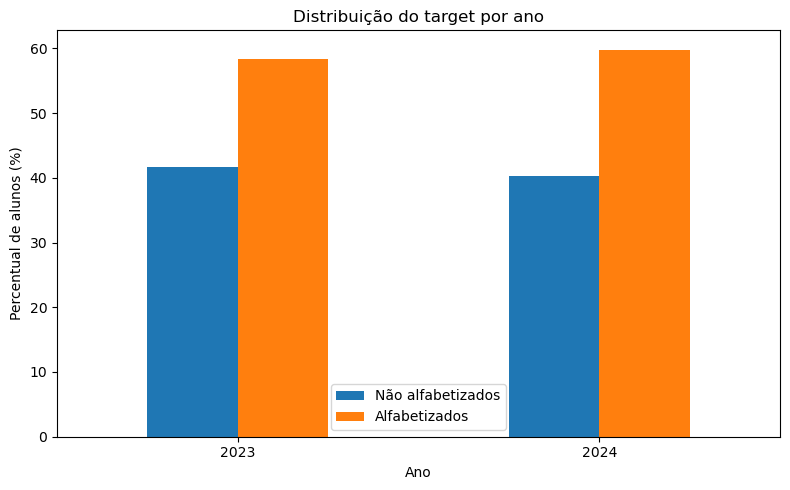

In [10]:
plot_target = target.set_index("ano")[
    [
        "pct_nao_alfabetizados",
        "pct_alfabetizados",
    ]
]

ax = plot_target.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title("Distribuição do target por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Percentual de alunos (%)")
ax.legend(
    [
        "Não alfabetizados",
        "Alfabetizados",
    ]
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
)

plt.tight_layout()

plt.savefig(
    IMAGES_PATH / "01_distribuicao_target.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Leitura

A taxa de alfabetização passou de aproximadamente 58,39% em 2023 para 59,78%
em 2024.

As classes permanecem suficientemente representadas para que o baseline seja
treinado inicialmente sem reamostragem artificial.

In [11]:
regiao = (
    df.groupby(
        ["ano", "regiao"],
        as_index=False,
    )
    .agg(
        alunos=(
            "quantidade_alunos",
            "sum",
        ),
        alfabetizados=(
            "quantidade_alfabetizados",
            "sum",
        ),
    )
)

regiao["taxa_alfabetizacao"] = (
    100
    * regiao["alfabetizados"]
    / regiao["alunos"]
)

regiao.sort_values(
    ["ano", "taxa_alfabetizacao"],
    ascending=[True, False],
)

,ano,regiao,alunos,alfabetizados,taxa_alfabetizacao
4,2023,Sul,298701,202300,67.7266
3,2023,Sudeste,362799,214469,59.1151
0,2023,Centro-Oeste,157677,93047,59.0111
1,2023,Nordeste,503043,275316,54.7301
2,2023,Norte,180589,92295,51.1078
5,2024,Centro-Oeste,175205,113353,64.6974
8,2024,Sudeste,744637,463862,62.2937
9,2024,Sul,278403,169753,60.9738
6,2024,Nordeste,465488,264668,56.8582
7,2024,Norte,188119,95483,50.7567


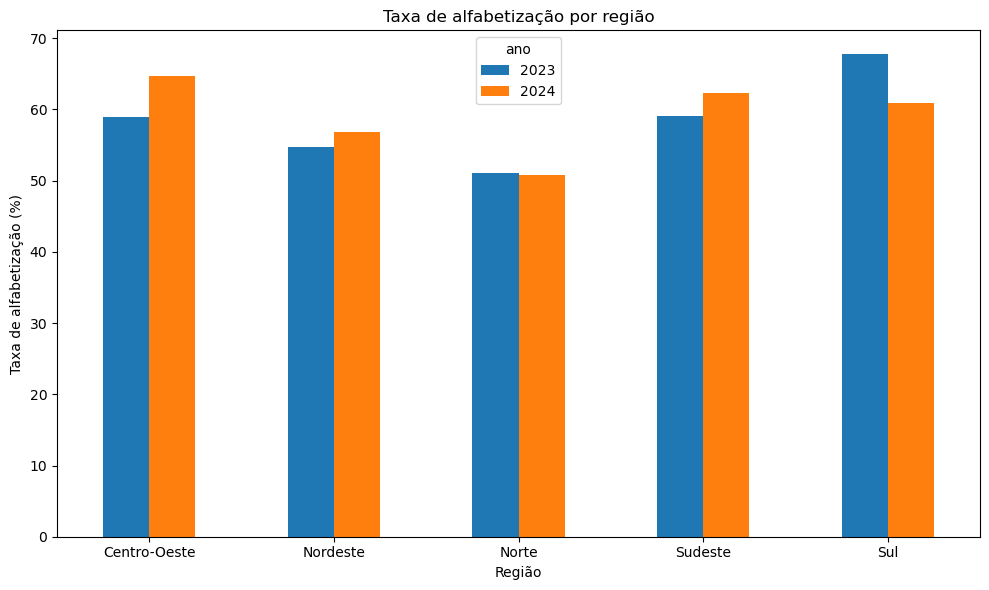

In [12]:
pivot_regiao = (
    regiao.pivot(
        index="regiao",
        columns="ano",
        values="taxa_alfabetizacao",
    )
)

ax = pivot_regiao.plot(
    kind="bar",
    figsize=(10, 6),
)

ax.set_title("Taxa de alfabetização por região")
ax.set_xlabel("Região")
ax.set_ylabel("Taxa de alfabetização (%)")
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
)

plt.tight_layout()

plt.savefig(
    IMAGES_PATH / "02_taxa_por_regiao.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Leitura territorial

Existem diferenças relevantes entre regiões, porém a ordenação não permanece
constante entre os anos.

O Sul apresenta a maior taxa em 2023, enquanto o Centro-Oeste apresenta a maior
taxa em 2024.

Esse comportamento reforça que território pode ser relevante para a predição,
mas não deve ser interpretado como um efeito fixo ou causal.

In [13]:
rede = (
    df.groupby(
        ["ano", "rede_nome"],
        as_index=False,
    )
    .agg(
        alunos=(
            "quantidade_alunos",
            "sum",
        ),
        alfabetizados=(
            "quantidade_alfabetizados",
            "sum",
        ),
    )
)

rede["taxa_alfabetizacao"] = (
    100
    * rede["alfabetizados"]
    / rede["alunos"]
)

rede

,ano,rede_nome,alunos,alfabetizados,taxa_alfabetizacao
0,2023,Estadual,131522,80662,61.3297
1,2023,Municipal,1371287,796765,58.1034
2,2024,Estadual,241074,150760,62.5368
3,2024,Municipal,1610754,956343,59.3724
4,2024,Privada,24,16,66.6667


In [14]:
regiao_rede = (
    df.groupby(
        ["ano", "regiao", "rede_nome"],
        as_index=False,
    )
    .agg(
        alunos=(
            "quantidade_alunos",
            "sum",
        ),
        alfabetizados=(
            "quantidade_alfabetizados",
            "sum",
        ),
    )
)

regiao_rede["taxa_alfabetizacao"] = (
    100
    * regiao_rede["alfabetizados"]
    / regiao_rede["alunos"]
)

regiao_rede

,ano,regiao,rede_nome,alunos,alfabetizados,taxa_alfabetizacao
0,2023,Centro-Oeste,Estadual,3611,1810,50.1246
1,2023,Centro-Oeste,Municipal,154066,91237,59.2194
2,2023,Nordeste,Estadual,11152,4910,44.0280
3,2023,Nordeste,Municipal,491891,270406,54.9727
4,2023,Norte,Estadual,23053,13506,58.5867
5,2023,Norte,Municipal,157536,78789,50.0133
6,2023,Sudeste,Estadual,44145,29065,65.8398
7,2023,Sudeste,Municipal,318654,185404,58.1835
8,2023,Sul,Estadual,49561,31371,63.2978
9,2023,Sul,Municipal,249140,170929,68.6076


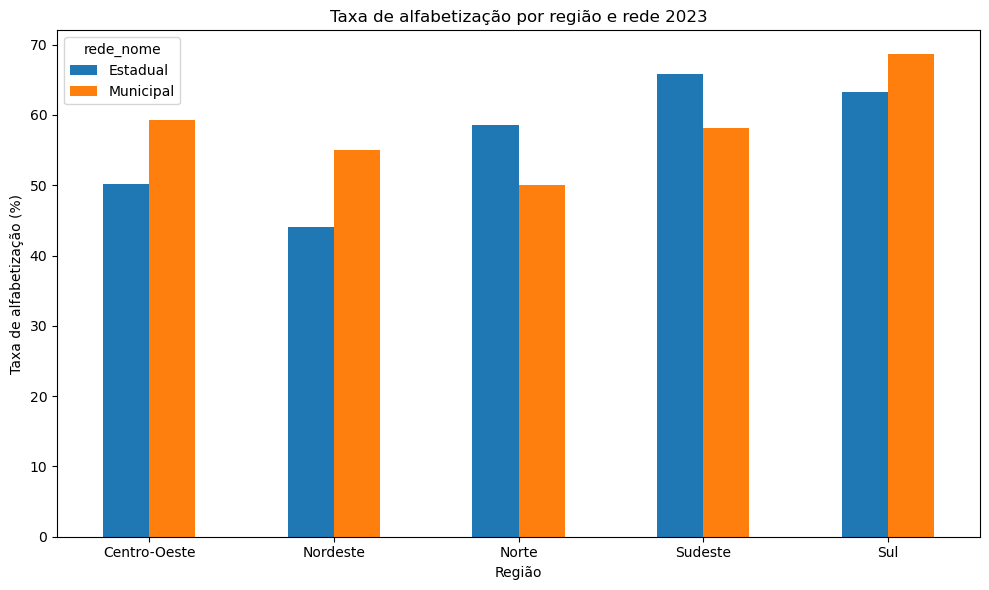

In [15]:
dados_2023 = (
    regiao_rede[
        regiao_rede["ano"] == 2023
    ]
    .pivot(
        index="regiao",
        columns="rede_nome",
        values="taxa_alfabetizacao",
    )
)

ax = dados_2023.plot(
    kind="bar",
    figsize=(10, 6),
)

ax.set_title(
    "Taxa de alfabetização por região e rede 2023"
)
ax.set_xlabel("Região")
ax.set_ylabel("Taxa de alfabetização (%)")
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
)

plt.tight_layout()

plt.savefig(
    IMAGES_PATH / "03_regiao_rede_2023.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

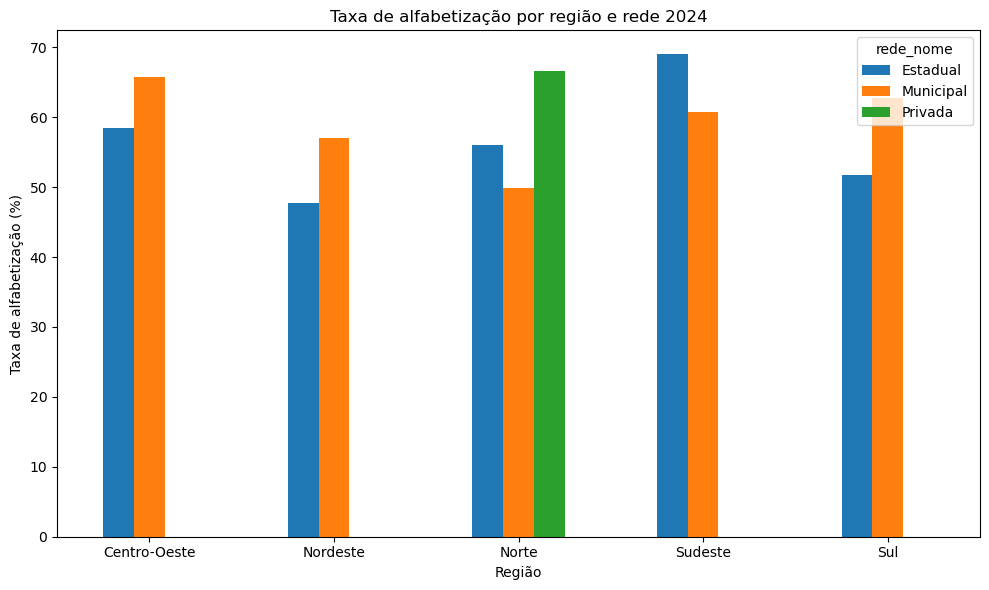

In [16]:
dados_2024 = (
    regiao_rede[
        regiao_rede["ano"] == 2024
    ]
    .pivot(
        index="regiao",
        columns="rede_nome",
        values="taxa_alfabetizacao",
    )
)

ax = dados_2024.plot(
    kind="bar",
    figsize=(10, 6),
)

ax.set_title(
    "Taxa de alfabetização por região e rede 2024"
)
ax.set_xlabel("Região")
ax.set_ylabel("Taxa de alfabetização (%)")
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
)

plt.tight_layout()

plt.savefig(
    IMAGES_PATH / "04_regiao_rede_2024.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Rede e território

A rede Estadual apresenta resultado agregado superior à Municipal nos dois anos,
mas esse padrão não é uniforme entre regiões.

Isso sugere interação entre contexto territorial e dependência administrativa.

A EDA não justifica ainda a criação manual de uma feature de interação. Essa
possibilidade será avaliada posteriormente, especialmente ao comparar modelos
lineares com modelos baseados em árvores.

In [17]:
resumo_municipal = (
    df_municipio.groupby("ano")[
        "taxa_alfabetizacao"
    ]
    .describe(
        percentiles=[0.25, 0.5, 0.75]
    )
)

resumo_municipal

,count,mean,std,min,25%,50%,75%,max
ano,,,,,,,,
2023,"4,871.0000",0.6092,0.1995,0.0455,0.4678,0.6210,0.7598,1.0000
2024,"5,517.0000",0.6328,0.1898,0.0000,0.4916,0.6437,0.7791,1.0000


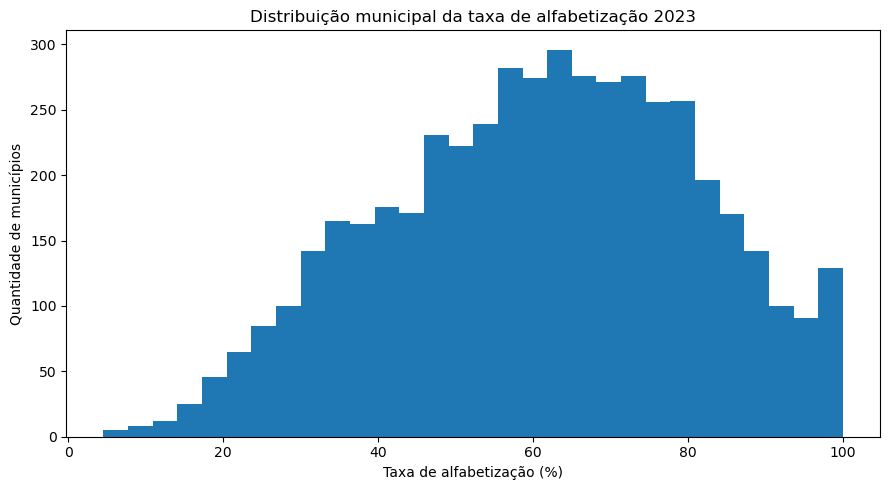

In [18]:
dados = (
    100
    * df_municipio.loc[
        df_municipio["ano"] == 2023,
        "taxa_alfabetizacao",
    ]
)

plt.figure(figsize=(9, 5))
plt.hist(
    dados,
    bins=30,
)

plt.title(
    "Distribuição municipal da taxa de alfabetização 2023"
)
plt.xlabel("Taxa de alfabetização (%)")
plt.ylabel("Quantidade de municípios")

plt.tight_layout()

plt.savefig(
    IMAGES_PATH / "05_distribuicao_municipal_2023.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

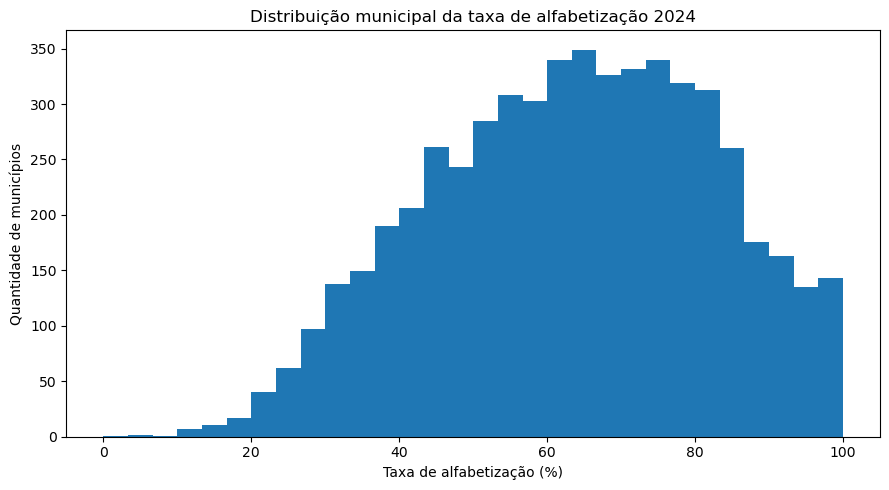

In [19]:
dados = (
    100
    * df_municipio.loc[
        df_municipio["ano"] == 2024,
        "taxa_alfabetizacao",
    ]
)

plt.figure(figsize=(9, 5))
plt.hist(
    dados,
    bins=30,
)

plt.title(
    "Distribuição municipal da taxa de alfabetização 2024"
)
plt.xlabel("Taxa de alfabetização (%)")
plt.ylabel("Quantidade de municípios")

plt.tight_layout()

plt.savefig(
    IMAGES_PATH / "06_distribuicao_municipal_2024.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Heterogeneidade municipal

A distribuição municipal evidencia grande dispersão.

Em 2023, a mediana municipal está próxima de 62,1%, enquanto em 2024 está
próxima de 64,4%.

A amplitude entre municípios é muito maior do que a variação observada na taxa
nacional, indicando que médias nacionais escondem diferenças territoriais
importantes.

In [20]:
df_municipio["log_populacao_2020"] = np.log1p(
    df_municipio["populacao_2020"]
)

df_municipio["log_pib_por_habitante_2020"] = np.log1p(
    df_municipio["pib_por_habitante_2020"]
)

df_municipio[
    [
        "populacao_2020",
        "log_populacao_2020",
        "pib_por_habitante_2020",
        "log_pib_por_habitante_2020",
    ]
].describe()

,populacao_2020,log_populacao_2020,pib_por_habitante_2020,log_pib_por_habitante_2020
count,"10,388.0000","10,388.0000","10,388.0000","10,388.0000"
mean,"35,754.2009",9.4641,"26,818.1721",9.9188
std,"191,998.8824",1.1641,"27,542.0549",0.6985
min,776.0000,6.6554,"4,920.6247",8.5014
25%,"5,444.0000",8.6025,"11,213.5037",9.3250
50%,"11,598.0000",9.3587,"19,317.7354",9.8688
75%,"25,237.0000",10.1361,"33,216.9544",10.4108
max,"12,325,232.0000",16.3272,"590,594.9400",13.2889


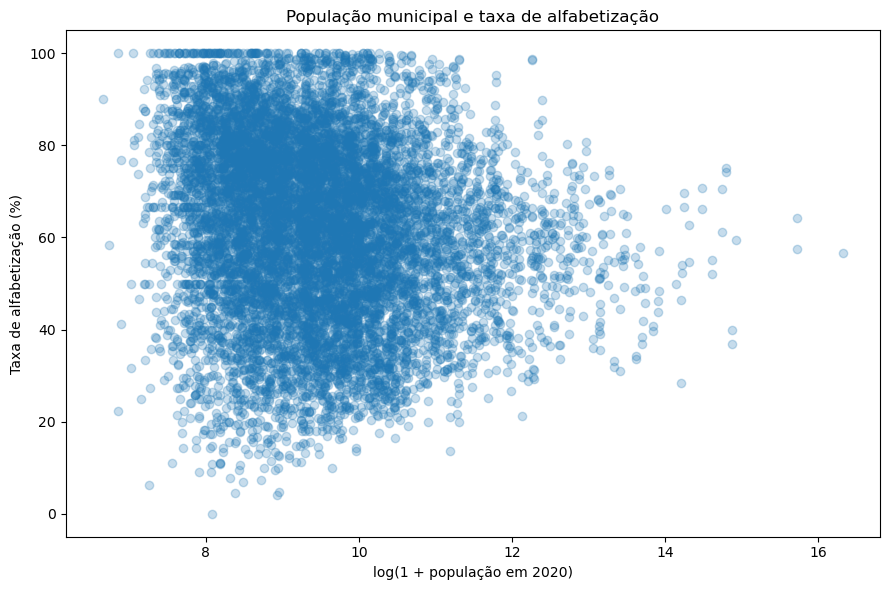

In [21]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_municipio["log_populacao_2020"],
    100 * df_municipio["taxa_alfabetizacao"],
    alpha=0.25,
)

plt.title(
    "População municipal e taxa de alfabetização"
)
plt.xlabel("log(1 + população em 2020)")
plt.ylabel("Taxa de alfabetização (%)")

plt.tight_layout()

plt.savefig(
    IMAGES_PATH / "07_populacao_alfabetizacao.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

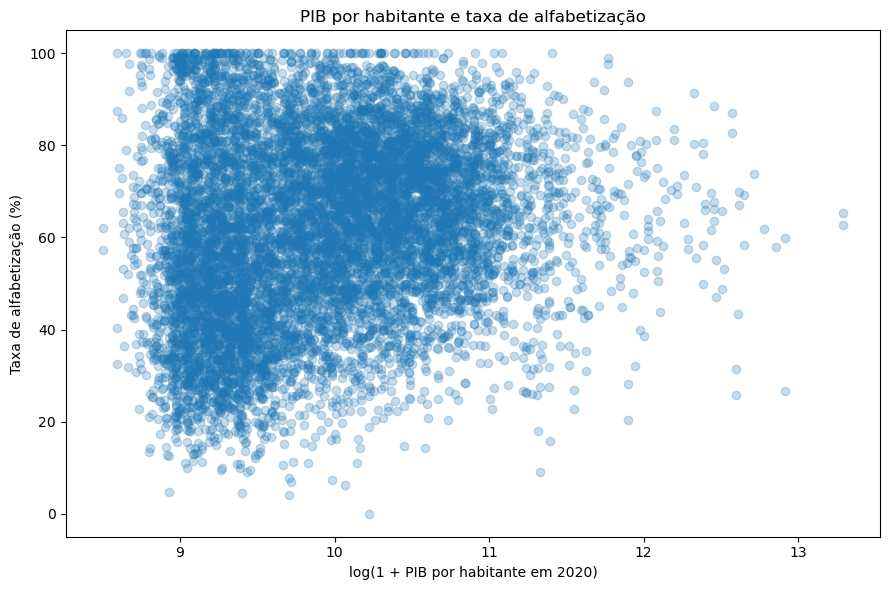

In [22]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df_municipio[
        "log_pib_por_habitante_2020"
    ],
    100 * df_municipio[
        "taxa_alfabetizacao"
    ],
    alpha=0.25,
)

plt.title(
    "PIB por habitante e taxa de alfabetização"
)
plt.xlabel(
    "log(1 + PIB por habitante em 2020)"
)
plt.ylabel(
    "Taxa de alfabetização (%)"
)

plt.tight_layout()

plt.savefig(
    IMAGES_PATH / "08_pib_alfabetizacao.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [23]:
variaveis_correlacao = [
    "populacao_2020",
    "pib_por_habitante_2020",
    "participacao_agropecuaria_2020",
    "participacao_industria_2020",
    "participacao_servicos_2020",
    "participacao_administracao_publica_2020",
]


correlacoes = []

for ano in sorted(
    df_municipio["ano"].unique()
):
    dados = df_municipio[
        df_municipio["ano"] == ano
    ]

    for coluna in variaveis_correlacao:

        valor = dados[
            [
                coluna,
                "taxa_alfabetizacao",
            ]
        ].corr().iloc[0, 1]

        correlacoes.append(
            {
                "ano": ano,
                "variavel": coluna,
                "correlacao": valor,
            }
        )


df_correlacoes = pd.DataFrame(
    correlacoes
)

df_correlacoes

,ano,variavel,correlacao
0,2023,populacao_2020,-0.0406
1,2023,pib_por_habitante_2020,0.1461
2,2023,participacao_agropecuaria_2020,0.1699
3,2023,participacao_industria_2020,0.0655
4,2023,participacao_servicos_2020,0.0787
5,2023,participacao_administracao_publica_2020,-0.2812
6,2024,populacao_2020,-0.0404
7,2024,pib_por_habitante_2020,0.0682
8,2024,participacao_agropecuaria_2020,0.1108
9,2024,participacao_industria_2020,0.0315


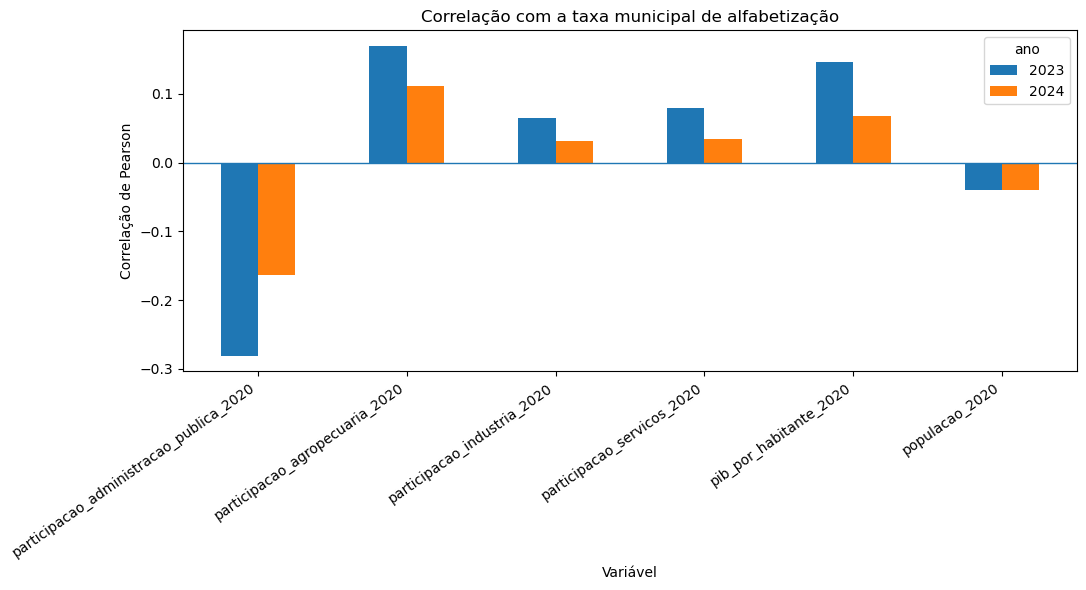

In [24]:
pivot_corr = (
    df_correlacoes.pivot(
        index="variavel",
        columns="ano",
        values="correlacao",
    )
)

ax = pivot_corr.plot(
    kind="bar",
    figsize=(11, 6),
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_title(
    "Correlação com a taxa municipal de alfabetização"
)
ax.set_xlabel("Variável")
ax.set_ylabel("Correlação de Pearson")
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=35,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    IMAGES_PATH / "09_correlacoes.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Associações socioeconômicas

As correlações são baixas ou moderadas.

Nenhuma das variáveis socioeconômicas analisadas apresenta associação linear
forte e isolada com a alfabetização.

A participação relativa da administração pública apresenta a maior correlação
em valor absoluto e é negativa nos dois anos.

Essas associações não demonstram causalidade e serão utilizadas apenas como
evidência exploratória para seleção e interpretação de features.

In [25]:
def taxa_por_variavel(df_base, coluna):

    resultado = (
        df_base.groupby(
            ["ano", coluna],
            as_index=False,
        )
        .agg(
            alunos=(
                "quantidade_alunos",
                "sum",
            ),
            alfabetizados=(
                "quantidade_alfabetizados",
                "sum",
            ),
        )
    )

    resultado["taxa_alfabetizacao"] = (
        100
        * resultado["alfabetizados"]
        / resultado["alunos"]
    )

    return resultado


taxa_capital = taxa_por_variavel(
    df,
    "capital_uf",
)

taxa_amazonia = taxa_por_variavel(
    df,
    "amazonia_legal",
)

display(taxa_capital)
display(taxa_amazonia)

,ano,capital_uf,alunos,alfabetizados,taxa_alfabetizacao
0,2023,0,1263699,744086,58.8816
1,2023,1,239110,133341,55.7655
2,2024,0,1501970,907308,60.4079
3,2024,1,349882,199811,57.1081


,ano,amazonia_legal,alunos,alfabetizados,taxa_alfabetizacao
0,2023,0,1219582,727698,59.6678
1,2023,1,283227,149729,52.8654
2,2024,0,1566479,952874,60.8290
3,2024,1,285373,154245,54.0503


In [26]:
municipios_2023 = set(
    df_municipio.loc[
        df_municipio["ano"] == 2023,
        "id_municipio",
    ]
)

municipios_2024 = set(
    df_municipio.loc[
        df_municipio["ano"] == 2024,
        "id_municipio",
    ]
)


cobertura = pd.DataFrame(
    {
        "categoria": [
            "Nos dois anos",
            "Somente 2023",
            "Somente 2024",
        ],
        "quantidade": [
            len(
                municipios_2023
                & municipios_2024
            ),
            len(
                municipios_2023
                - municipios_2024
            ),
            len(
                municipios_2024
                - municipios_2023
            ),
        ],
    }
)

cobertura

,categoria,quantidade
0,Nos dois anos,4841
1,Somente 2023,30
2,Somente 2024,676


In [27]:
taxas_2023 = (
    df_municipio[
        df_municipio["ano"] == 2023
    ][
        [
            "id_municipio",
            "taxa_alfabetizacao",
        ]
    ]
    .rename(
        columns={
            "taxa_alfabetizacao":
            "taxa_2023"
        }
    )
)


taxas_2024 = (
    df_municipio[
        df_municipio["ano"] == 2024
    ][
        [
            "id_municipio",
            "taxa_alfabetizacao",
        ]
    ]
    .rename(
        columns={
            "taxa_alfabetizacao":
            "taxa_2024"
        }
    )
)


comparacao = taxas_2023.merge(
    taxas_2024,
    on="id_municipio",
    how="inner",
)


comparacao["variacao"] = (
    comparacao["taxa_2024"]
    - comparacao["taxa_2023"]
)


comparacao.describe()

,taxa_2023,taxa_2024,variacao
count,"4,841.0000","4,841.0000","4,841.0000"
mean,0.6090,0.6312,0.0222
std,0.1992,0.1952,0.1663
min,0.0455,0.0000,-0.8489
25%,0.4675,0.4796,-0.0646
50%,0.6209,0.6460,0.0211
75%,0.7588,0.7829,0.1188
max,1.0000,1.0000,0.9048


In [28]:
correlacao_temporal = (
    comparacao[
        [
            "taxa_2023",
            "taxa_2024",
        ]
    ]
    .corr()
    .iloc[0, 1]
)


mediana_variacao_abs = (
    comparacao["variacao"]
    .abs()
    .median()
)


media_variacao_abs = (
    comparacao["variacao"]
    .abs()
    .mean()
)


print(
    f"Municípios comparáveis: "
    f"{len(comparacao):,}"
)

print(
    f"Correlação 2023 x 2024: "
    f"{correlacao_temporal:.3f}"
)

print(
    "Variação absoluta média: "
    f"{100 * media_variacao_abs:.2f} pp"
)

print(
    "Variação absoluta mediana: "
    f"{100 * mediana_variacao_abs:.2f} pp"
)

Municípios comparáveis: 4,841
Correlação 2023 x 2024: 0.644
Variação absoluta média: 12.53 pp
Variação absoluta mediana: 9.43 pp


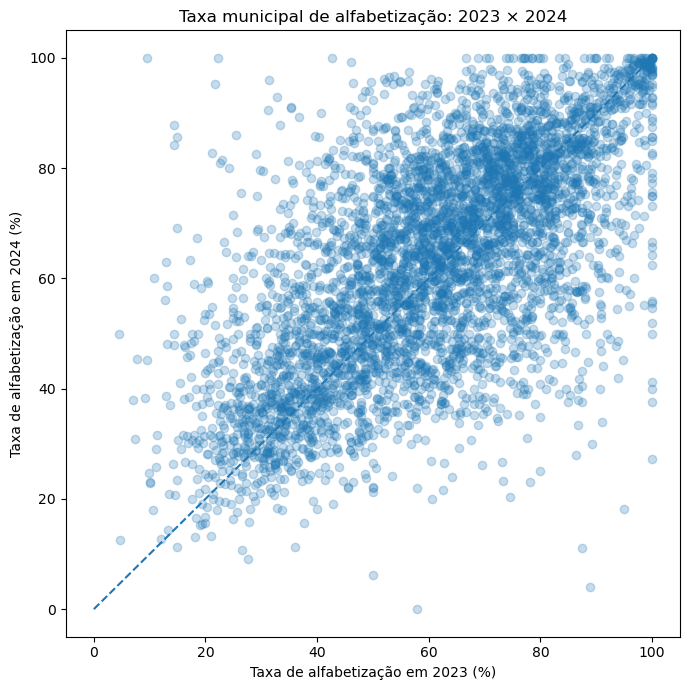

In [29]:
plt.figure(figsize=(7, 7))

plt.scatter(
    100 * comparacao["taxa_2023"],
    100 * comparacao["taxa_2024"],
    alpha=0.25,
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
)

plt.title(
    "Taxa municipal de alfabetização: 2023 × 2024"
)
plt.xlabel(
    "Taxa de alfabetização em 2023 (%)"
)
plt.ylabel(
    "Taxa de alfabetização em 2024 (%)"
)

plt.tight_layout()

plt.savefig(
    IMAGES_PATH / "10_comparacao_municipal_2023_2024.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## Generalização temporal e territorial

Dos 5.547 municípios presentes no universo combinado:

- 4.841 aparecem nos dois anos;
- 30 aparecem apenas em 2023;
- 676 aparecem apenas em 2024.

A correlação das taxas de alfabetização entre os municípios comparáveis é
aproximadamente 0,644.

Apesar da persistência moderada, a variação absoluta mediana entre os anos é
próxima de 9,43 pontos percentuais.

Isso indica que o teste de 2024 representa simultaneamente:

1. generalização para um período posterior;
2. mudança do comportamento municipal;
3. generalização para centenas de municípios que não aparecem no conjunto de
   desenvolvimento de 2023.

Por esse motivo, a avaliação final deverá apresentar métricas para:

- todo o conjunto de 2024;
- municípios observados em 2023;
- municípios novos em 2024.

In [30]:
achados = pd.DataFrame(
    [
        {
            "tema": "Target",
            "achado": (
                "Classes moderadamente desbalanceadas; "
                "sem necessidade inicial de SMOTE."
            ),
        },
        {
            "tema": "Território",
            "achado": (
                "Diferenças regionais relevantes, "
                "mas não estáveis entre anos."
            ),
        },
        {
            "tema": "Rede",
            "achado": (
                "A relação entre rede e alfabetização "
                "varia entre regiões."
            ),
        },
        {
            "tema": "Municípios",
            "achado": (
                "Grande heterogeneidade nas taxas "
                "de alfabetização."
            ),
        },
        {
            "tema": "População e PIB",
            "achado": (
                "Distribuições fortemente assimétricas; "
                "log1p será avaliado."
            ),
        },
        {
            "tema": "Socioeconomia",
            "achado": (
                "Associações lineares baixas ou moderadas; "
                "nenhuma variável isolada domina."
            ),
        },
        {
            "tema": "Temporal",
            "achado": (
                "Persistência municipal moderada, "
                "com variação relevante entre anos."
            ),
        },
        {
            "tema": "Generalização",
            "achado": (
                "676 municípios de 2024 não aparecem "
                "em 2023."
            ),
        },
    ]
)

achados

,tema,achado
0,Target,Classes moderadamente desbalanceadas; sem nece...
1,Território,"Diferenças regionais relevantes, mas não estáv..."
2,Rede,A relação entre rede e alfabetização varia ent...
3,Municípios,Grande heterogeneidade nas taxas de alfabetiza...
4,População e PIB,Distribuições fortemente assimétricas; log1p s...
5,Socioeconomia,Associações lineares baixas ou moderadas; nenh...
6,Temporal,"Persistência municipal moderada, com variação ..."
7,Generalização,676 municípios de 2024 não aparecem em 2023.


## Conclusões da EDA

A análise exploratória mostrou que a alfabetização apresenta forte
heterogeneidade territorial e que nenhuma variável socioeconômica isolada
explica o resultado.

Foram identificadas diferenças entre regiões e redes de ensino, porém essas
diferenças não permanecem constantes entre os anos, indicando que interações
entre contexto territorial, características administrativas e fatores
socioeconômicos podem ser relevantes.

População e PIB por habitante apresentam distribuições fortemente assimétricas,
o que justifica testar transformações logarítmicas no pipeline de modelos
lineares.

A existência de 676 municípios no conjunto de 2024 que não aparecem em 2023
também torna a avaliação temporal particularmente relevante para testar
generalização fora dos territórios observados durante o desenvolvimento.

### Estratégia definida para a próxima etapa

- desenvolvimento e seleção do modelo utilizando 2023;
- preservação integral de 2024 como teste temporal final;
- pré-processamento integrado ao pipeline;
- tratamento de categorias desconhecidas;
- comparação entre modelos lineares e não lineares;
- análise separada de desempenho em municípios conhecidos e novos;
- avaliação posterior de Feature Importance e SHAP.

As relações identificadas nesta EDA são associações estatísticas e não devem
ser interpretadas como evidência causal.